# Experiment 5: Fixing the Straight-Line with Fallback

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Performance_measuring import test_dmp_performance

ModuleNotFoundError: No module named 'Performance_measuring'

## Spatial Coupling Function with Fallback Active

Same as Experiment 4 with the 3D fallback block

In [ ]:
import numpy as np

def spatial_coupling_OA(
        y, 
        ydot, 
        obstacles, 
        gamma=1000.0, 
        beta=6.0, 
        eps=1e-9
        ):

    #turn into 1D vectors
    y = np.asarray(y).reshape(-1,)
    ydot = np.asarray(ydot).reshape(-1,)

    
    d_dim = y.shape[0] # number or rows 3 in this case
    Ct_total = np.zeros(d_dim) # coupling terms for each obstacle

    vnorm = np.linalg.norm(ydot) # normalizes velocity
    if vnorm < eps:
        # steering angle is meaningless when stationary
        return Ct_total
 
    for o in obstacles:
        o = np.asarray(o).reshape(-1,) # 1D vector
        dvec = o - y # getting difference
        dnorm = np.linalg.norm(dvec) # getting normailized difference
        if dnorm < eps: # angle would be meaning less
            continue

        cosang = np.dot(dvec, ydot) / (dnorm * vnorm + eps)
        cosang = np.clip(cosang, -1.0, 1.0) # sure within range
        psi = np.arccos(cosang) # steering angle between 0 and pi

        # Compute R ydot
        if d_dim == 2:
            # choose side based on sign of (d x v)_z
            cross_z = dvec[0]*ydot[1] - dvec[1]*ydot[0]
            sign = 1.0 if cross_z >= 0 else -1.0 
            Rydot = sign * np.array([-ydot[1], ydot[0]]) # apply 90 degree rotaion - sign controls clockwise or anticlockwise

        elif d_dim == 3:
            r = np.cross(dvec, ydot)
            rnorm = np.linalg.norm(r)

            # FALLBACK  if r ~ 0 (d parallel to v)
            if rnorm < eps:  
                a = np.array([1.0, 0.0, 0.0])
                if abs(np.dot(a, ydot)/(np.linalg.norm(a)*vnorm + eps))>0.9:
                    a=np.array([0.0, 1.0, 0.0])
                r = np.cross(a, ydot)
                rnorm = np.linalg.norm(r)
                if rnorm < eps:
                    continue
            
            rhat = r / (rnorm+eps)

            #  simplified Rodrigues for theta = pi/2:
            Rydot = np.cross(rhat, ydot) + rhat * np.dot(rhat, ydot)

        else:
            raise ValueError("Only 2D or 3D supported.")

        Ct_total += gamma * Rydot * psi * np.exp(-beta * psi)
          
    return Ct_total


# DMP & OA

In [ ]:
def dmp_discrete_3d_OA(
    pos, 
    dt,
    kp=150.0, 
    kv=25.0, 
    alpha=5.0, 
    basis_num=40,
    speed=1.0,
    start_shift=None,
    goal_shift=None,
    spatial_scale=None,
    init_vel_scale=1.0,
    init_vel_offset=None,
    obstacles=None,
    oa_gamma=1000.0,
    oa_beta=6.0
):   
    pos = np.asarray(pos) # checks demonstration is in correct form
    assert pos.ndim == 2 and pos.shape[0] == 3, "pos must be shape (3, T)"
    assert speed > 0, "speed must be > 0"

    if obstacles is None:
        obstacles = []

    T = pos.shape[1] # number of intervals

    tau_demo = dt * T # duration of the demonstration (for learning)
    tau_new  = tau_demo / speed # new duration of demonstration

    vel = np.gradient(pos, axis=-1)/dt # velocity using derivative
    acc = np.gradient(vel, axis=-1)/dt # acceleration

    # Goal / start  shift and speed setup
    goal = pos[:, -1]
    demo_start = pos[:, 0]
    demo_goal  = pos[:, -1]

    if start_shift is None:
        start_shift = np.zeros(3)
    if goal_shift is None:
        goal_shift = np.zeros(3)

    start_shift = np.asarray(start_shift).reshape(3,)
    goal_shift  = np.asarray(goal_shift).reshape(3,)

    newStart = demo_start+start_shift # new start pos
    newGoal  = demo_goal +goal_shift # new goal pos

    if init_vel_offset is None:
        init_vel_offset = np.zeros(3)
    init_vel_offset = np.asarray(init_vel_offset).reshape(3,)


    demo_displacement = demo_goal - demo_start
    new_displacement  = newGoal - newStart

    if spatial_scale is None:
        spatial_scale = np.ones(3)
        for d in range(3):
            if abs(demo_displacement[d]) > 1e-8:
                spatial_scale[d] = new_displacement[d] / demo_displacement[d]
    else:
        spatial_scale = np.asarray(spatial_scale).reshape(3,)

    # basis setup
    u = np.zeros(basis_num)
    c = np.zeros(basis_num)
    h = np.zeros(basis_num)

    # control center loactions of gaussians
    for i in range(basis_num):
        u[i] = (1.0/basis_num)*i
        c[i] = np.exp(-alpha * u[i])

    # control spread of gaussians
    for i in range(basis_num - 1):
        h[i] = 0.5 / ((0.65 * (c[i+1] - c[i]))**2) # controling 
    h[basis_num - 1] = h[basis_num - 2]

    #  Learning
    Phi = np.zeros(basis_num)
    Phi_total = np.zeros((T, basis_num))
    force = np.zeros((T, 3))

    s = 1.0
    for i in range(T):
        # canonical system 
        s = -alpha*s*dt/tau_demo+s
    
        addsum = 0.0
        for b in range(basis_num):
            Phi[b] = np.exp(-h[b] * (s - c[b])**2)
            addsum += Phi[b]
        Phi = Phi / addsum * s
        Phi_total[i, :] = Phi

        # target forcing term
        force[i, :] = (tau_demo*tau_demo)*acc[:, i] - kp*(goal - pos[:, i]) + tau_demo*kv*vel[:, i]

    trainPattern = np.matmul(np.linalg.pinv(Phi_total), force)  # (basis_num, 3)

    # setup for reconstruction
    T_new = int(np.round(tau_new / dt)) # note the use tau_new so that the reconstruction happens at the wanted speed
    T_new = max(T_new, 2)

    DMP_pos = np.zeros((3, T_new))
    DMP_vel = np.zeros((3, T_new))
    DMP_acc = np.zeros((3, T_new))

    DMP_pos[:, 0] = newStart 
    DMP_vel[:, 0] = init_vel_scale * vel[:, 0] + init_vel_offset

    s = 1.0
    for i in range(T_new - 1):
        s = -alpha*s*dt/tau_new+s
        addsum = 0.0
        
        for b in range(basis_num):
            Phi[b] = np.exp(-h[b] * (s - c[b])**2)
            addsum = addsum + Phi[b]

        newForce = np.matmul(Phi / addsum, trainPattern) * s * spatial_scale

        # obstacle avoidance coupling term
        Ct = spatial_coupling_OA(
            DMP_pos[:, i],
            DMP_vel[:, i],
            obstacles,
            gamma=oa_gamma,
            beta=oa_beta
        )

        # transformation system
        DMP_acc[:, i] = (kp*(newGoal - DMP_pos[:, i]) - tau_new*kv*DMP_vel[:, i] + newForce + Ct) / (tau_new**2)
        DMP_pos[:, i+1] = DMP_pos[:, i] + DMP_vel[:, i] * dt
        DMP_vel[:, i+1] = DMP_vel[:, i] + DMP_acc[:, i] * dt

    return DMP_pos, DMP_vel, DMP_acc, trainPattern, tau_new, newStart, newGoal

## Multi-View Plotting Helper

In [ ]:
def plot_dmp_views_points(pos, DMP_pos, objects, newGoal=None,
        views=((20, 45), (20, 135), (60, 45), (10, -60))):
    objs = np.asarray(objects, dtype=float).reshape(-1, 3)

    # combine all points to compute a shared axis range
    P = np.column_stack([pos[0], pos[1], pos[2]])
    Q = np.column_stack([DMP_pos[0], DMP_pos[1], DMP_pos[2]])
    pts = np.vstack([P, Q, objs])

    if newGoal is not None:
        pts = np.vstack([pts, np.asarray(newGoal, dtype=float).reshape(1, 3)])

    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    max_range = float(np.max(maxs - mins))
    min_val = float(np.min(mins))

    fig = plt.figure(figsize=(10, 10))
    for i, (elev, azim) in enumerate(views[:4], start=1):
        ax = fig.add_subplot(2, 2, i, projection="3d")

        ax.plot(pos[0], pos[1], pos[2], label="demo")
        ax.plot(DMP_pos[0], DMP_pos[1], DMP_pos[2], label="DMP")
        ax.scatter(objs[:, 0], objs[:, 1], objs[:, 2], marker='o', s=80, label="obstacle")

        if newGoal is not None:
            g = np.asarray(newGoal, dtype=float).reshape(3,)
            ax.scatter(g[0], g[1], g[2], marker='x', s=60, label="goal")
        else:
            ax.scatter(pos[0, -1], pos[1, -1], pos[2, -1], marker='x', s=60, label="goal")

        ax.set_xlim(min_val, min_val + max_range)
        ax.set_ylim(min_val, min_val + max_range)
        ax.set_zlim(min_val, min_val + max_range)

        ax.set_xlabel("x"); 
        ax.set_ylabel("y"); 
        ax.set_zlabel("z")

        ax.view_init(elev=elev, azim=azim) # set the view angle for better visualization
        ax.legend()

    plt.tight_layout()
    plt.show()

## Example 1 — Straight Line with Single Obstacle

min dist (DMP -> obstacle): 0.0627


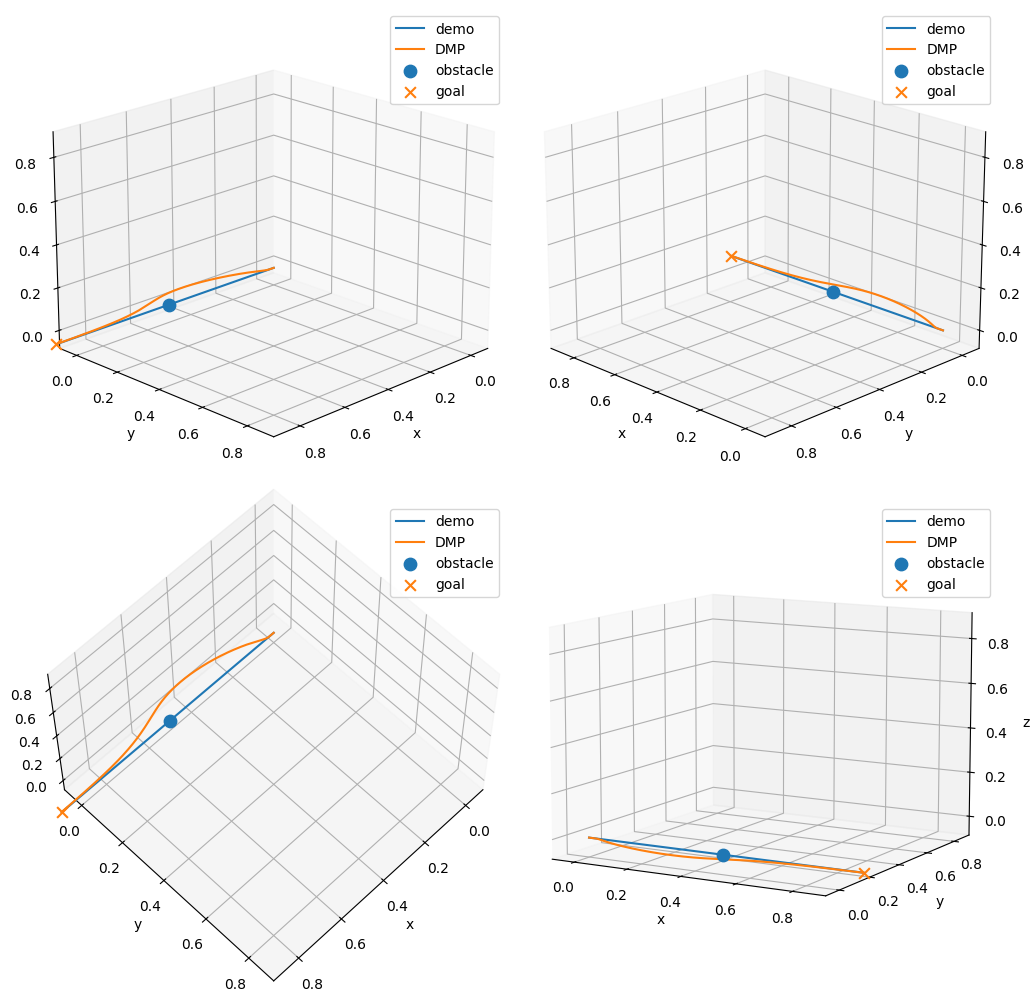

In [ ]:
dt = 0.005

# straight-line demo
T = int(np.round(2.0 / dt))
t_demo = np.linspace(0, 2.0, T)

start = np.array([0.0, 0.0, 0.0])
goal  = np.array([1.0, 0.0, 0.0])

u = t_demo / 2.0
pos = np.vstack([
    start[0] + (goal[0] - start[0]) * u,
    start[1] + (goal[1] - start[1]) * u,
    start[2] + (goal[2] - start[2]) * u,
])

# obstacle at the midpoint of the line (directly on the path)
mid = pos.shape[1] // 2
obstacle = pos[:, mid].copy()
obstacles = [obstacle]

DMP_pos, DMP_vel, DMP_acc, W, tau_new, newStart, newGoal = dmp_discrete_3d_OA(
    pos, dt,
    speed=1.0,
    obstacles=obstacles,
    oa_gamma=1000.0,
    oa_beta=6,
)

d_dmp = np.min(np.linalg.norm(DMP_pos.T - obstacle[None, :], axis=1))
print(f"min dist (DMP -> obstacle): {d_dmp:.4f}")

plot_dmp_views_points(pos, DMP_pos, objects=[obstacle], newGoal=newGoal)

## Example 2 — Straight Line with Multiple Obstacles


min dist (DMP -> obstacle 1): 0.1477
min dist (DMP -> obstacle 2): 0.0600
min dist (DMP -> obstacle 3): 0.2345
min dist (DMP -> obstacle 4): 0.1016
min dist (DMP -> obstacle 5): 0.2452


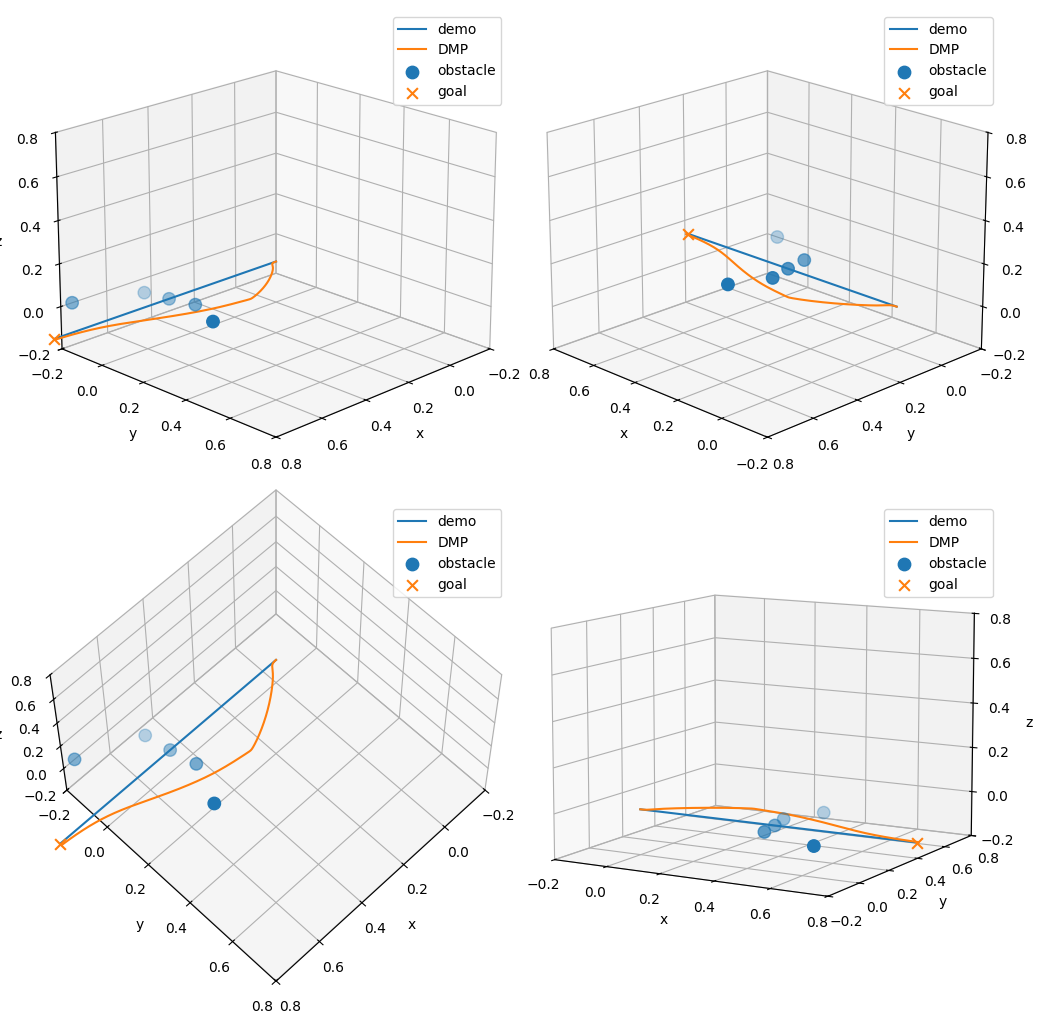

In [ ]:
# same straight-line demo as above
dt = 0.005
T = int(np.round(2.0 / dt))
t_demo = np.linspace(0, 2.0, T)

start = np.array([0, 0, 0])
goal  = np.array([1.0, 0, 0])

u = t_demo / 2.0
pos = np.vstack([
    start[0] + (goal[0] - start[0]) * u,
    start[1] + (goal[1] - start[1]) * u,
    start[2] + (goal[2] - start[2]) * u,
])

# five obstacles along the path — one directly on the line, others offset
mid = pos.shape[1] // 2
obstacle_1 = pos[:, mid] + np.array([0, 0, 0])   # on the line
obstacle_2 = pos[:, mid -10] + np.array([0,  0.10, 0])
obstacle_3 = pos[:, mid + 8] + np.array([0, -0.10, 0])
obstacle_4 = pos[:, mid + 15] + np.array([0,  0.25, 0])
obstacle_5 = pos[:, mid + 100] + np.array([0, -0.20, 0])

obstacles = [obstacle_1, obstacle_2, obstacle_3, obstacle_4, obstacle_5]

DMP_pos, DMP_vel, DMP_acc, W, tau_new, newStart, newGoal = dmp_discrete_3d_OA(
    pos, dt,
    speed=1.0,
    obstacles=obstacles,
    oa_gamma=1000.0,
    oa_beta=6,
)

for i, obs in enumerate(obstacles):
    d = np.min(np.linalg.norm(DMP_pos.T - obs[None, :], axis=1))
    print(f"min dist (DMP -> obstacle {i+1}): {d:.4f}")

plot_dmp_views_points(pos, DMP_pos, objects=obstacles, newGoal=newGoal)

## Performance Evaluation

Goal error, tracking error, and minimum obstacle clearance for both examples.

In [ ]:
# Example 1
dt = 0.005
T = int(np.round(2.0 / dt))
t_demo = np.linspace(0, 2.0, T)
u = t_demo / 2.0
pos1 = np.vstack([u, np.zeros_like(u), np.zeros_like(u)])
obs1 = pos1[:, T // 2].copy()

DMP1, _, _, _, _, _, _ = dmp_discrete_3d_OA(
    pos1, dt, obstacles=[obs1], oa_gamma=1000.0, oa_beta=6.31
)
_, metrics1 = test_dmp_performance(pos1, DMP1, obstacle_positions=[obs1])




# Example 2 
mid = pos1.shape[1] // 2
obs_list2 = [
    pos[:, mid] + np.array([0, 0, 0]),
    pos[:, mid -10] + np.array([0,  0.10, 0]),
    pos[:, mid + 8] + np.array([0, -0.10, 0]),
    pos[:, mid + 15] + np.array([0,  0.25, 0]),
    pos[:, mid + 100] + np.array([0, -0.20, 0])
]

DMP2, _, _, _, _, _, _ = dmp_discrete_3d_OA(
    pos1, dt, obstacles=obs_list2, oa_gamma=1000.0, oa_beta=6.31
)
_, metrics2 = test_dmp_performance(pos1, DMP2, obstacle_positions=obs_list2)




print("Example 1")
for k, v in metrics1.items():
    print(f"  {k}: {v}")

print()
print("Example 2 — Five obstacles")
for k, v in metrics2.items():
    print(f"  {k}: {v}")

Example 1
  final_goal_error: 0.0008945687827571644
  RMS_tracking_error: 0.0474210019796764
  min_distance_each_obstacle: [0.058846916657174744]
  min_distance_overall: 0.058846916657174744
  original_path_length: 1.0
  DMP_path_length: 1.020935308892093

Example 2 — Five obstacles
  final_goal_error: 0.005567794288732143
  RMS_tracking_error: 0.1133390363397908
  min_distance_each_obstacle: [0.13359196447331573, 0.046043312188043854, 0.22051782392420582, 0.11564134508732214, 0.23768529684711523]
  min_distance_overall: 0.046043312188043854
  original_path_length: 1.0
  DMP_path_length: 1.0785994527342462
